<a href="https://colab.research.google.com/github/ShreshthaPandey/JOSAA-collage-predictor/blob/main/clg_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [181]:
import zipfile

with zipfile.ZipFile("/content/archive (13).zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [182]:
import os

for year in range(2016, 2020):
    for round in range(1, 6):

        file = f"dataset/{year}_round_{round}.csv"

        if os.path.exists(file):
            os.remove(file)

In [183]:
import os

files = os.listdir("dataset")
files

['2020_round_2.csv',
 '2022.csv',
 '2025.csv',
 '2023_round_3.csv',
 '2022_round_5.csv',
 '2023.csv',
 '2020_round_1.csv',
 '2025_round_3.csv',
 '2023_round_6.csv',
 '2021_round_3.csv',
 '2018_round_6.csv',
 '2022_round_6.csv',
 '2025_round_2.csv',
 '2023_round_4.csv',
 '2025_round_6.csv',
 '2018_round_7.csv',
 '2017_round_6.csv',
 '2023_round_1.csv',
 '2025_round_1.csv',
 '2023_round_2.csv',
 '2025_round_5.csv',
 '2022_round_1.csv',
 '2022_round_2.csv',
 '2021_round_2.csv',
 '2024_round_5.csv',
 '2020_round_3.csv',
 '2022_round_3.csv',
 '2024.csv',
 '2024_round_3.csv',
 '2016_round_6.csv',
 '2024_round_1.csv',
 '2024_round_2.csv',
 '2021.csv',
 '2026_round_1.csv',
 '2020_round_5.csv',
 '2019_round_7.csv',
 '2022_round_4.csv',
 '2021_round_5.csv',
 '2021_round_6.csv',
 '2023_round_5.csv',
 '2020_round_6.csv',
 '2024_round_4.csv',
 '2020.csv',
 '2026.csv',
 '2019_round_6.csv',
 '2021_round_4.csv',
 '2021_round_1.csv',
 '2020_round_4.csv',
 '2025_round_4.csv',
 '2017_round_7.csv',
 'jee_

In [184]:
df = pd.read_csv("dataset/jee_exam_dynamics.csv")
df

,Year,Number_of_JEE_applicants_registered,Total_number_of_seats
0,2026,"15,38,468",67323
1,2025,"14,75,103",62853
2,2024,"14,15,110",57152
3,2023,"11,62,398",56874
4,2022,"10,26,799",54477
5,2021,"10,48,012",52453
6,2020,"11,74,103",50822
7,2019,"12,37,892",45235
8,2018,"11,35,084",37473
9,2017,"11,86,454",36268


In [185]:
df.drop([7 , 8 , 9 , 10])

,Year,Number_of_JEE_applicants_registered,Total_number_of_seats
0,2026,"15,38,468",67323
1,2025,"14,75,103",62853
2,2024,"14,15,110",57152
3,2023,"11,62,398",56874
4,2022,"10,26,799",54477
5,2021,"10,48,012",52453
6,2020,"11,74,103",50822


In [186]:
import os
import pandas as pd

for file in os.listdir("dataset"):
    if file.endswith(".csv"):

        path = os.path.join("dataset", file)
        df = pd.read_csv(path)

        print("\nFile:", file)
        print("Rows:", len(df))
        print("Columns:", list(df.columns))


File: 2020_round_2.csv
Rows: 9138
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2022.csv
Rows: 58880
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank', 'round']


/tmp/ipykernel_7284/3293744942.py:8: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)



File: 2025.csv
Rows: 72189
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank', 'round']

File: 2023_round_3.csv
Rows: 10404
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2022_round_5.csv
Rows: 9764
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2023.csv
Rows: 62865
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank', 'round']

File: 2020_round_1.csv
Rows: 9338
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2025_round_3.csv
Rows: 11982
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2023_round_6.csv
Rows: 10366
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gende

In [187]:
import os
import pandas as pd

years = range(2020, 2027)

for year in years:
    all_data = []

    for file in os.listdir("dataset"):
        if file.startswith(f"{year}_round_") and file.endswith(".csv"):

            path = os.path.join("dataset", file)
            df = pd.read_csv(path)

            # Round number extract karo
            round_no = file.split("_")[2].replace(".csv", "")

            # New column
            df["round"] = round_no

            all_data.append(df)

    # Saare rounds merge
    if all_data:
        merged_df = pd.concat(all_data, ignore_index=True)

        # Save
        merged_df.to_csv(f"dataset/{year}.csv", index=False)

        print(f"{year}: {len(merged_df)} rows")

2020: 54614 rows
2021: 55590 rows
2022: 58880 rows
2023: 62865 rows
2024: 56918 rows
2025: 72189 rows
2026: 13292 rows


In [188]:
df0 = pd.read_csv("dataset/2020.csv")
df1 = pd.read_csv("dataset/2021.csv")
df2 = pd.read_csv("dataset/2022.csv")
df3 = pd.read_csv("dataset/2023.csv")
df3 = pd.read_csv("dataset/2024.csv")
df5 = pd.read_csv("dataset/2025.csv")
df6 = pd.read_csv("dataset/2026.csv")


/tmp/ipykernel_7284/917474916.py:6: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df5 = pd.read_csv("dataset/2025.csv")


In [189]:
df0.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2
2,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN (PwD),Gender-Neutral,56P,56P,2
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2


In [190]:
df0.groupby("round").size()

,0
round,
1,9338
2,9138
3,9069
4,9045
5,9033
6,8991


In [191]:
import pandas as pd

all_data = []

for year in range(2020, 2027):
    file = f"dataset/{year}.csv"

    df = pd.read_csv(file)

    # Year column add karo
    df["year"] = year

    all_data.append(df)

# All years merge
final_df = pd.concat(all_data, ignore_index=True)

print(final_df.shape)
final_df.head()

(374348, 9)


/tmp/ipykernel_7284/812342895.py:8: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020
2,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN (PwD),Gender-Neutral,56P,56P,2,2020
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020


In [192]:
final_df.describe()

,round,year
count,374348.000000,374348.000000
mean,3.319652,2022.752289
std,1.707683,1.801642
min,1.000000,2020.000000
25%,2.000000,2021.000000
50%,3.000000,2023.000000
75%,5.000000,2024.000000
max,6.000000,2026.000000


In [193]:
final_df.isnull().sum()

,0
Institute,35
Academic Program Name,35
Quota,35
Seat Type,35
Gender,35
Opening Rank,35
Closing Rank,35
round,0
year,0


In [194]:
final_df[final_df["Academic Program Name"].isnull()]
final_df = final_df.dropna()

In [195]:
final_df.isnull().sum()

,0
Institute,0
Academic Program Name,0
Quota,0
Seat Type,0
Gender,0
Opening Rank,0
Closing Rank,0
round,0
year,0


In [196]:
final_df.shape

(374313, 9)

In [197]:
final_df.duplicated().sum()

np.int64(0)

In [198]:
df = final_df

In [199]:
df.shape

(374313, 9)

In [200]:
df.head(1)

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020


In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374313 entries, 0 to 374347
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Institute              374313 non-null  object
 1   Academic Program Name  374313 non-null  object
 2   Quota                  374313 non-null  object
 3   Seat Type              374313 non-null  object
 4   Gender                 374313 non-null  object
 5   Opening Rank           374313 non-null  object
 6   Closing Rank           374313 non-null  object
 7   round                  374313 non-null  int64 
 8   year                   374313 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 28.6+ MB


In [202]:
df.describe()

,round,year
count,374313.000000,374313.000000
mean,3.319642,2022.752317
std,1.707685,1.801648
min,1.000000,2020.000000
25%,2.000000,2021.000000
50%,3.000000,2023.000000
75%,5.000000,2024.000000
max,6.000000,2026.000000


In [203]:
df.groupby('Opening Rank').size()

,0
Opening Rank,
3.0,1
4.0,1
5.0,1
6.0,1
7.0,2
...,...
99987,5
9999,6
99P,7


In [204]:
# df[df['Opening Rank'] == '99P']
df = df[
    ~(
        df["Opening Rank"].astype(str).str.contains("P", na=False) |
        df["Closing Rank"].astype(str).str.contains("P", na=False)
    )
]



In [205]:
df["Opening Rank"].dtype

dtype('O')

In [206]:
df["Closing Rank"].dtype

dtype('O')

In [207]:
df['Opening Rank'] = df['Opening Rank'].astype('float32')
df['Closing Rank'] = df['Closing Rank'].astype('float32')

/tmp/ipykernel_7284/2070766959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Opening Rank'] = df['Opening Rank'].astype('float32')
/tmp/ipykernel_7284/2070766959.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Closing Rank'] = df['Closing Rank'].astype('float32')


In [208]:
df.sort_values("Opening Rank", ascending=False)

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
368756,"National Institute of Technology, Mizoram",Electronics and Communication Engineering (4 Y...,HS,OPEN,Female-only (including Supernumerary),1497038.0,1497038.0,1,2026
307948,"National Institute of Technology, Mizoram","Chemical Science and Technology (4 Years, Bach...",HS,OPEN,Gender-Neutral,1274910.0,1274910.0,2,2025
308000,"National Institute of Technology, Mizoram","Mathematics and Computing (4 Years, Bachelor o...",HS,OPEN,Female-only (including Supernumerary),1210797.0,1210797.0,2,2025
273120,"National Institute of Technology, Mizoram","Mathematics and Computing (4 Years, Bachelor o...",HS,OPEN,Female-only (including Supernumerary),1079883.0,1079883.0,2,2024
332079,"National Institute of Technology, Mizoram","Mathematics and Computing (4 Years, Bachelor o...",HS,OPEN,Female-only (including Supernumerary),1019344.0,1019344.0,1,2025
...,...,...,...,...,...,...,...,...,...
301009,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,SC,Gender-Neutral,1.0,31.0,2,2025
313061,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,ST (PwD),Gender-Neutral,1.0,1.0,6,2025
313058,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,SC (PwD),Gender-Neutral,1.0,1.0,6,2025
313056,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,SC,Gender-Neutral,1.0,31.0,6,2025


In [209]:
print("Opening Rank NaN:", df["Opening Rank"].isna().sum())
print("Closing Rank NaN:", df["Closing Rank"].isna().sum())

print("Opening Rank inf:", np.isinf(df["Opening Rank"]).sum())
print("Closing Rank inf:", np.isinf(df["Closing Rank"]).sum())

Opening Rank NaN: 0
Closing Rank NaN: 0
Opening Rank inf: 0
Closing Rank inf: 0


In [210]:
df = df[~(np.isinf(df["Closing Rank"]))]
df = df[~(np.isinf(df["Opening Rank"]))]

In [211]:
df['Closing Rank'].max()

1497038.0

In [212]:
df["Opening Rank"] = df["Opening Rank"].astype('int32')
df["Closing Rank"] = df["Closing Rank"].astype('int32')
df['round'] = df['round'].astype('int16')
df['year'] = df['year'].astype('int16')

In [213]:
df['Closing Rank'].max()

1497038

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366914 entries, 0 to 374347
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Institute              366914 non-null  object
 1   Academic Program Name  366914 non-null  object
 2   Quota                  366914 non-null  object
 3   Seat Type              366914 non-null  object
 4   Gender                 366914 non-null  object
 5   Opening Rank           366914 non-null  int32 
 6   Closing Rank           366914 non-null  int32 
 7   round                  366914 non-null  int16 
 8   year                   366914 non-null  int16 
dtypes: int16(2), int32(2), object(5)
memory usage: 21.0+ MB


In [215]:
df.shape

(366914, 9)

In [216]:
df.groupby("Opening Rank").size()

,0
Opening Rank,
1,211
2,158
3,207
4,182
5,194
...,...
1019344,1
1079883,1
1210797,1


In [217]:
df.groupby("Quota").size()

,0
Quota,
AI,148160
AI,6028
GO,1181
GO,37
HS,95205
HS,3291
JK,2579
JK,80
LA,432


In [218]:
df.groupby("Institute").size().sort_values(ascending=False)


,0
Institute,
"National Institute of Technology, Rourkela",13917
Indian Institute of Technology Kharagpur,11162
"National Institute of Technology, Warangal",9180
National Institute of Technology Raipur,9140
"Dr. B R Ambedkar National Institute of Technology, Jalandhar",8892
...,...
"National Institute of Electronics and Information Technology, Srinagar",8
"National Institute of Electronics and Information Technology, Agartala",7
"National Institute of Electronics and Information Technology, Imphal",6


In [219]:
max_iit_crl = df[(df['Seat Type'] == 'OPEN') & (df['Quota'] == 'AI')]['Closing Rank'].max()
print("Max IIT CRL:", max_iit_crl)

# Max CRL Rank for NITs/IIITs/GFTIs (Home State and Other State Quotas)
max_nit_crl = df[(df['Seat Type'] == 'OPEN') & (df['Quota'].isin(['HS', 'OS']))]['Closing Rank'].max()
print("Max NIT/IIIT CRL:", max_nit_crl)

Max IIT CRL: 125271
Max NIT/IIIT CRL: 1368129


In [220]:
df.describe()

,Opening Rank,Closing Rank,round,year
count,3.669140e+05,3.669140e+05,366914.000000,366914.000000
mean,1.135986e+04,1.414337e+04,3.318884,2022.768308
std,3.052512e+04,4.031729e+04,1.707595,1.797408
min,1.000000e+00,1.000000e+00,1.000000,2020.000000
25%,1.319000e+03,1.574000e+03,2.000000,2021.000000
50%,4.044000e+03,4.845000e+03,3.000000,2023.000000
75%,1.067500e+04,1.285675e+04,5.000000,2024.000000
max,1.497038e+06,1.497038e+06,6.000000,2026.000000


Your predictor works for    →  Ranks 1 to ~40,000

Students above rank 40,000  →  "No JoSAA colleges available"

                               You can show this message to them

In [221]:
df[df['Opening Rank'] < 0]

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year


In [222]:

df = df[df['Closing Rank'] > 0]
df = df[df['Opening Rank'] > 0]

In [223]:
# Check if any opening rank > closing rank (data error)
bad_rows = df[df['Opening Rank'] > df['Closing Rank']]
print(f"Bad rows: {len(bad_rows)}")

Bad rows: 0


In [224]:
df.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020


In [225]:
df.describe()

,Opening Rank,Closing Rank,round,year
count,3.669140e+05,3.669140e+05,366914.000000,366914.000000
mean,1.135986e+04,1.414337e+04,3.318884,2022.768308
std,3.052512e+04,4.031729e+04,1.707595,1.797408
min,1.000000e+00,1.000000e+00,1.000000,2020.000000
25%,1.319000e+03,1.574000e+03,2.000000,2021.000000
50%,4.044000e+03,4.845000e+03,3.000000,2023.000000
75%,1.067500e+04,1.285675e+04,5.000000,2024.000000
max,1.497038e+06,1.497038e+06,6.000000,2026.000000


In [226]:
# Check which rows have suspiciously high ranks
bad = df[df['Closing Rank'] > 100000]
print(f"Bad rows count: {len(bad)}")
print(bad['year'].value_counts())
print(bad.head(5))

Bad rows count: 5618
year
2025    1252
2024     895
2021     858
2023     830
2020     813
2022     772
2026     198
Name: count, dtype: int64
                                      Institute  \
3512  National Institute of Technology Agartala   
3513  National Institute of Technology Agartala   
3528  National Institute of Technology Agartala   
3529  National Institute of Technology Agartala   
3548  National Institute of Technology Agartala   

                                  Academic Program Name Quota Seat Type  \
3512  Biotechnology and Biochemical Engineering (4 Y...    HS      OPEN   
3513  Biotechnology and Biochemical Engineering (4 Y...    HS      OPEN   
3528  Chemical Engineering (4 Years, Bachelor of Tec...    HS      OPEN   
3529  Chemical Engineering (4 Years, Bachelor of Tec...    HS      OPEN   
3548  Chemistry (5 Years, Bachelor of Science and Ma...    HS      OPEN   

                                     Gender  Opening Rank  Closing Rank  \
3512                    

In [227]:
df.describe()

,Opening Rank,Closing Rank,round,year
count,3.669140e+05,3.669140e+05,366914.000000,366914.000000
mean,1.135986e+04,1.414337e+04,3.318884,2022.768308
std,3.052512e+04,4.031729e+04,1.707595,1.797408
min,1.000000e+00,1.000000e+00,1.000000,2020.000000
25%,1.319000e+03,1.574000e+03,2.000000,2021.000000
50%,4.044000e+03,4.845000e+03,3.000000,2023.000000
75%,1.067500e+04,1.285675e+04,5.000000,2024.000000
max,1.497038e+06,1.497038e+06,6.000000,2026.000000


In [228]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'round', 'year'],
      dtype='object')

In [229]:
df.shape

(366914, 9)

In [230]:
df['year'].describe()

,year
count,366914.000000
mean,2022.768308
std,1.797408
min,2020.000000
25%,2021.000000
50%,2023.000000
75%,2024.000000
max,2026.000000


In [231]:
# # Save the cleaned dataframe to a new CSV file
# df.to_csv('josaa_cleaned.csv', index=False)

# # Download it
# from google.colab import files
# files.download('josaa_cleaned.csv')

# print(f"✅ Saved and downloading!")
# print(f"Shape: {df.shape}")
# print(f"Columns: {df.columns.tolist()}")

In [232]:
df.head()


,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020


In [233]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 366914 entries, 0 to 374347
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Institute              366914 non-null  object
 1   Academic Program Name  366914 non-null  object
 2   Quota                  366914 non-null  object
 3   Seat Type              366914 non-null  object
 4   Gender                 366914 non-null  object
 5   Opening Rank           366914 non-null  int32 
 6   Closing Rank           366914 non-null  int32 
 7   round                  366914 non-null  int16 
 8   year                   366914 non-null  int16 
dtypes: int16(2), int32(2), object(5)
memory usage: 21.0+ MB


In [234]:
df = df.rename(columns={'year' : 'Year',
                   })


In [235]:
df["Year"].value_counts()

,count
Year,
2025,71414
2023,62083
2022,58321
2024,55961
2021,53416
2020,52634
2026,13085


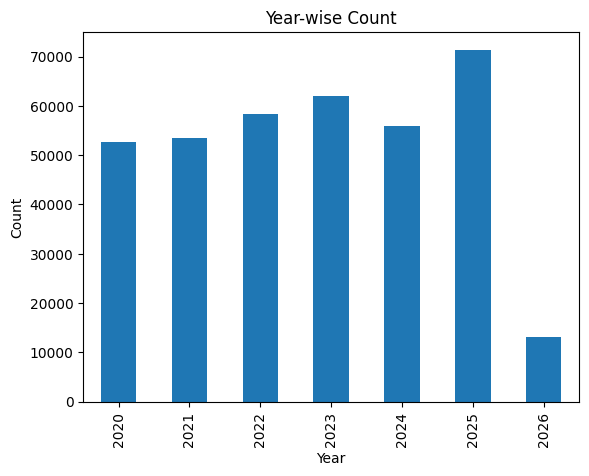

In [236]:
import matplotlib.pyplot as plt

df["Year"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Year-wise Count")
plt.show()

In [237]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'round', 'Year'],
      dtype='object')

In [238]:
df = df.rename(columns={'round' : 'Round'})

In [239]:
df['Round'].value_counts()

,count
Round,
1,75434
2,60896
3,60549
4,60464
5,60410
6,49161


In [240]:
df = df[df['Round'] <6]
df.shape

(317753, 9)

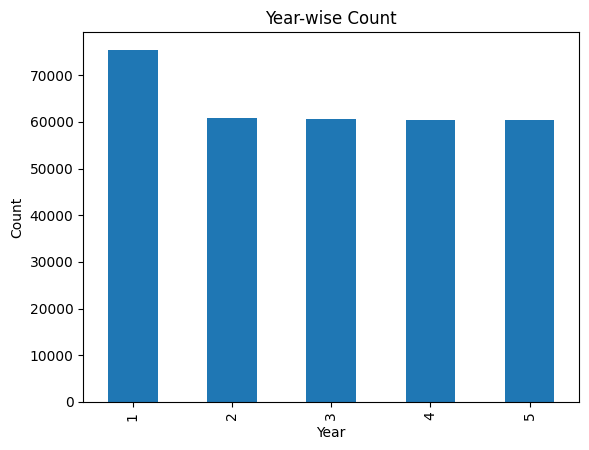

In [241]:
import matplotlib.pyplot as plt

df["Round"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Year-wise Count")
plt.show()

In [242]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [243]:
df['Opening Rank'].value_counts().sort_index(ascending=False)
df['Closing Rank'].value_counts().sort_index(ascending=False)

,count
Closing Rank,
1497038,1
1368129,2
1317736,1
1314967,4
1294100,1
...,...
5,112
4,125
3,143


/tmp/ipykernel_7284/3841245975.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


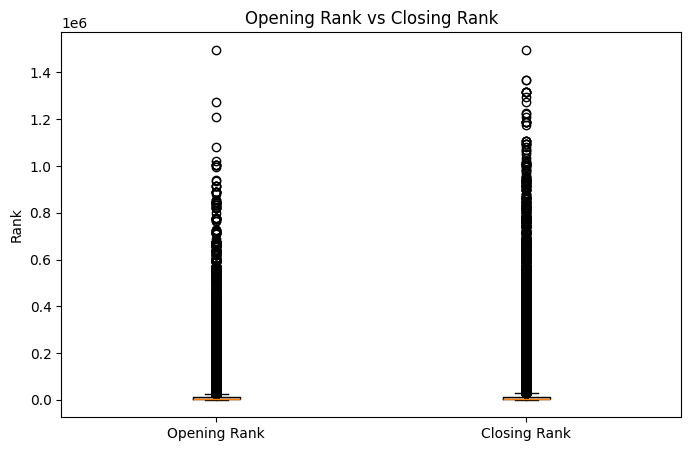

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [df["Opening Rank"], df["Closing Rank"]],
    labels=["Opening Rank", "Closing Rank"]
)

plt.ylabel("Rank")
plt.title("Opening Rank vs Closing Rank")
plt.show()

In [245]:
df['Closing Rank'].info()
df['Closing Rank'].max()
df['Closing Rank'].min()

<class 'pandas.core.series.Series'>
Index: 317753 entries, 0 to 374347
Series name: Closing Rank
Non-Null Count   Dtype
--------------   -----
317753 non-null  int32
dtypes: int32(1)
memory usage: 3.6 MB


1

In [246]:
df['Opening Rank'].info()
df['Opening Rank'].max()
df['Opening Rank'].min()

<class 'pandas.core.series.Series'>
Index: 317753 entries, 0 to 374347
Series name: Opening Rank
Non-Null Count   Dtype
--------------   -----
317753 non-null  int32
dtypes: int32(1)
memory usage: 3.6 MB


1

In [247]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [248]:
df['Gender'].value_counts()

,count
Gender,
Gender-Neutral,190778
Female-only (including Supernumerary),113890
Gender-Neutral,8390
Female-only (including Supernumerary),4695


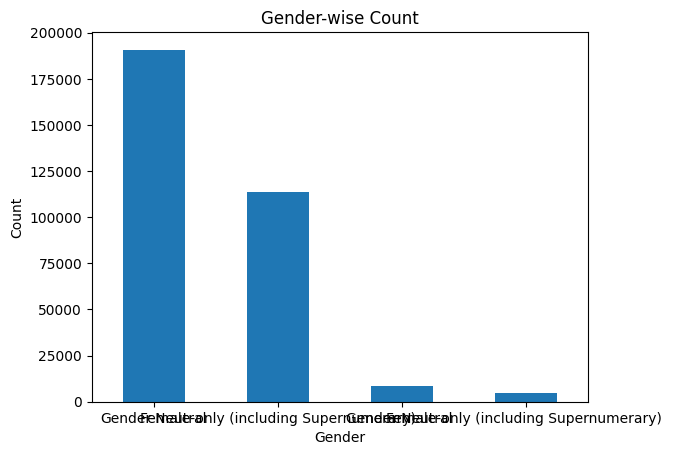

In [249]:
import matplotlib.pyplot as plt

gender_count = df["Gender"].value_counts()

gender_count.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender-wise Count")
plt.xticks(rotation=0)
plt.show()

In [250]:
df["Gender"] = df["Gender"].str.strip()

In [251]:
df['Gender'].value_counts()

,count
Gender,
Gender-Neutral,199168
Female-only (including Supernumerary),118585


In [252]:
df['Seat Type'].value_counts()

,count
Seat Type,
OPEN,61797
OBC-NCL,56330
SC,55907
EWS,51101
ST,47107
OPEN (PwD),17120
OBC-NCL (PwD),9262
EWS (PwD),2868
OPEN,2566


In [253]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [254]:
df['Quota'].value_counts()


,count
Quota,
AI,127676
OS,91418
HS,81963
AI,6028
OS,3635
HS,3291
JK,2218
GO,1023
LA,370


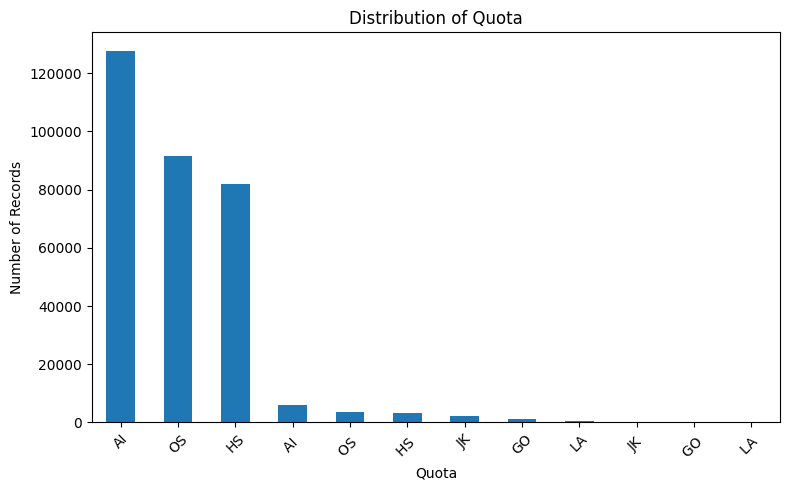

In [255]:
import matplotlib.pyplot as plt

quota_count = df['Quota'].value_counts()

quota_count.plot(kind='bar', figsize=(8, 5))

plt.xlabel('Quota')
plt.ylabel('Number of Records')
plt.title('Distribution of Quota')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [256]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [257]:
df['Academic Program Name'].value_counts().sort_values()


,count
Academic Program Name,
"B.Tech. (Food Engineering and Technology) - MBA (5 Years, Bachelor of Technology and MBA (Dual Degree))",3
"B.Tech. (Elctrical Engineering) - MBA (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
"B.Tech. (Civil Engineering) - MBA (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
"B.Tech (Mathematics and Computing) - MBA in Digital Business Management (IIM Bodh Gaya) (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
"B.Tech (Chemical Science and Technology) - MBA in Hospital and Health Care Management (IIM Bodh Gaya) (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
...,...
"Electrical Engineering (4 Years, Bachelor of Technology)",20662
"Civil Engineering (4 Years, Bachelor of Technology)",26662
"Mechanical Engineering (4 Years, Bachelor of Technology)",29088


In [258]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [259]:
df['Institute'].value_counts().sort_values()

,count
Institute,
"National Institute of Electronics and Information Technology, Calicut",6
"National Institute of Electronics and Information Technology, Imphal",6
"National Institute of Electronics and Information Technology, Kohima",6
"National Institute of Electronics and Information Technology, Agartala",7
"National Institute of Electronics and Information Technology, Srinagar",8
...,...
"Dr. B R Ambedkar National Institute of Technology, Jalandhar",7702
National Institute of Technology Raipur,7881
"National Institute of Technology, Warangal",7958


In [260]:
df['Seat Type'].value_counts()

,count
Seat Type,
OPEN,61797
OBC-NCL,56330
SC,55907
EWS,51101
ST,47107
OPEN (PwD),17120
OBC-NCL (PwD),9262
EWS (PwD),2868
OPEN,2566


In [261]:
# Check exact values with repr
print(df['Seat Type'].apply(repr).value_counts().head(10))

# Fix — strip whitespace and standardise
df['Seat Type'] = df['Seat Type'].str.strip()

# Check again
print(df['Seat Type'].value_counts())

Seat Type
'OPEN'             61797
'OBC-NCL'          56330
'SC'               55907
'EWS'              51101
'ST'               47107
'OPEN (PwD)'       17120
'OBC-NCL (PwD)'     9262
'EWS (PwD)'         2868
'OPEN '             2566
'OBC-NCL '          2383
Name: count, dtype: int64
Seat Type
OPEN             64363
OBC-NCL          58713
SC               58192
EWS              53185
ST               49087
OPEN (PwD)       17997
OBC-NCL (PwD)     9796
EWS (PwD)         3030
SC (PwD)          2458
ST (PwD)           932
Name: count, dtype: int64


In [262]:
import re

# 1. Clean whitespace first
df['Seat Type'] = df['Seat Type'].str.strip()

# 2. Extract PwD flag
df['is_pwd'] = df['Seat Type'].str.contains('PwD', case=False).astype(int)

# 3. Extract clean base category
df['category'] = df['Seat Type'].str.replace(r'\s*\(PwD\)', '',
                                              regex=True).str.strip()

# 4. Verify
print(df[['Seat Type', 'category', 'is_pwd']].value_counts())
print(f"\nUnique categories: {df['category'].unique()}")
print(f"PwD rows: {df['is_pwd'].sum():,}")
print(f"Non-PwD rows: {(df['is_pwd']==0).sum():,}")

Seat Type      category  is_pwd
OPEN           OPEN      0         64363
OBC-NCL        OBC-NCL   0         58713
SC             SC        0         58192
EWS            EWS       0         53185
ST             ST        0         49087
OPEN (PwD)     OPEN      1         17997
OBC-NCL (PwD)  OBC-NCL   1          9796
EWS (PwD)      EWS       1          3030
SC (PwD)       SC        1          2458
ST (PwD)       ST        1           932
Name: count, dtype: int64

Unique categories: ['OPEN' 'EWS' 'OBC-NCL' 'SC' 'ST']
PwD rows: 34,213
Non-PwD rows: 283,540


In [263]:
df.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Round,Year,is_pwd,category
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020,0,OPEN
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020,0,OPEN
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020,0,EWS
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020,0,EWS
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020,0,OBC-NCL


In [264]:
# df['seat_type_main'].value_counts()

In [265]:
df.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Round,Year,is_pwd,category
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020,0,OPEN
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020,0,OPEN
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020,0,EWS
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020,0,EWS
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020,0,OBC-NCL


In [266]:
df['seat_type_main'] = (
    df['Seat Type']
    .str.replace(r'\s*\(PwD\)', '', regex=True)
    .str.strip()
)

print(df[['Seat Type', 'seat_type_main', 'is_pwd']].drop_duplicates())

         Seat Type seat_type_main  is_pwd
0             OPEN           OPEN       0
3              EWS            EWS       0
5          OBC-NCL        OBC-NCL       0
7               SC             SC       0
9               ST             ST       0
37      OPEN (PwD)           OPEN       1
43   OBC-NCL (PwD)        OBC-NCL       1
192      EWS (PwD)            EWS       1
198       SC (PwD)             SC       1
201       ST (PwD)             ST       1


In [267]:
df['Category'] = (
    df['Seat Type']
    .str.replace(r'\s*\(PwD\)', '', regex=True)
    .str.strip()
)

In [268]:
df.drop(columns={'category' ,'seat_type_main' })

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Round,Year,is_pwd,Category
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020,0,OPEN
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020,0,OPEN
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020,0,EWS
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020,0,EWS
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020,0,OBC-NCL
...,...,...,...,...,...,...,...,...,...,...,...
374343,"Central University of Punjab, Bathinda","Computer Science and Engineering (4 Years, Bac...",AI,OPEN (PwD),Gender-Neutral,3241,3250,1,2026,1,OPEN
374344,"Central University of Punjab, Bathinda","Computer Science and Engineering (4 Years, Bac...",AI,EWS,Gender-Neutral,9501,9747,1,2026,0,EWS
374345,"Central University of Punjab, Bathinda","Computer Science and Engineering (4 Years, Bac...",AI,OBC-NCL,Gender-Neutral,20309,22289,1,2026,0,OBC-NCL
374346,"Central University of Punjab, Bathinda","Computer Science and Engineering (4 Years, Bac...",AI,SC,Gender-Neutral,7785,10736,1,2026,0,SC


In [269]:
df['is_pwd'].value_counts()
df['Category'].value_counts()

,count
Category,
OPEN,82360
OBC-NCL,68509
SC,60650
EWS,56215
ST,50019


In [270]:
def get_institute_type(name):
    name = str(name).upper()
    if 'INDIAN INSTITUTE OF TECHNOLOGY' in name:
        return 'IIT'
    elif 'NATIONAL INSTITUTE OF TECHNOLOGY' in name:
        return 'NIT'
    elif 'INDIAN INSTITUTE OF INFORMATION TECHNOLOGY' in name:
        return 'IIIT'
    else:
        return 'GFTI'

df['Institute Type'] = df['Institute'].apply(get_institute_type)

# Verify
print(df['Institute Type'].value_counts())

Institute Type
NIT     169873
IIT      84051
GFTI     38077
IIIT     25752
Name: count, dtype: int64


In [271]:
df.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Round,Year,is_pwd,category,seat_type_main,Category,Institute Type
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020,0,OPEN,OPEN,OPEN,IIT
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020,0,OPEN,OPEN,OPEN,IIT
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020,0,EWS,EWS,EWS,IIT
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020,0,EWS,EWS,EWS,IIT
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020,0,OBC-NCL,OBC-NCL,OBC-NCL,IIT


In [272]:
df['Institute Type'].value_counts()

,count
Institute Type,
NIT,169873
IIT,84051
GFTI,38077
IIIT,25752


In [273]:
df['Institute']

,Institute
0,Indian Institute of Technology Bhubaneswar
1,Indian Institute of Technology Bhubaneswar
3,Indian Institute of Technology Bhubaneswar
4,Indian Institute of Technology Bhubaneswar
5,Indian Institute of Technology Bhubaneswar
...,...
374343,"Central University of Punjab, Bathinda"
374344,"Central University of Punjab, Bathinda"
374345,"Central University of Punjab, Bathinda"
374346,"Central University of Punjab, Bathinda"


In [274]:
# Complete health check
print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== SAMPLE ROWS ===")
print(df.head(3).to_string())

print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== VALUE COUNTS ===")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== SHAPE ===
(317753, 14)

=== COLUMNS ===
['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank', 'Round', 'Year', 'is_pwd', 'category', 'seat_type_main', 'Category', 'Institute Type']

=== DTYPES ===
Institute                object
Academic Program Name    object
Quota                    object
Seat Type                object
Gender                   object
Opening Rank              int32
Closing Rank              int32
Round                     int16
Year                      int16
is_pwd                    int64
category                 object
seat_type_main           object
Category                 object
Institute Type           object
dtype: object

=== NULL VALUES ===
Institute                0
Academic Program Name    0
Quota                    0
Seat Type                0
Gender                   0
Opening Rank             0
Closing Rank             0
Round                    0
Year                     0
is_pwd                  

In [275]:
# ── 1. Find where LA is coming from ──────────────────
for col in df.select_dtypes(include='object').columns:
    if df[col].str.contains('LA', na=False).any():
        print(f"LA found in: {col}")
        print(df[df[col].str.contains('LA', na=False)][col].value_counts())

# ── 2. Drop duplicate category columns ───────────────
cols_to_drop = []

# Drop Seat Type (already extracted to Category)
if 'Seat Type' in df.columns:
    cols_to_drop.append('Seat Type')

# Drop duplicate category columns — keep only 'Category'
if 'category' in df.columns:
    cols_to_drop.append('category')
if 'seat_type_main' in df.columns:
    cols_to_drop.append('seat_type_main')

df = df.drop(columns=cols_to_drop)
print(f"✅ Dropped: {cols_to_drop}")

# ── 3. Remove duplicate columns (safety check) ───────
df = df.loc[:, ~df.columns.duplicated()]

# ── 4. Drop LA rows ───────────────────────────────────
# (run after finding which column has LA)
# df = df[df['column_name'] != 'LA']

# ── 5. Final check ────────────────────────────────────
print("\n=== FINAL COLUMNS ===")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
print("\n=== NULL CHECK ===")
print(df.isnull().sum())

LA found in: Quota
Quota
LA     370
LA      14
Name: count, dtype: int64
✅ Dropped: ['Seat Type', 'category', 'seat_type_main']

=== FINAL COLUMNS ===
['Institute', 'Academic Program Name', 'Quota', 'Gender', 'Opening Rank', 'Closing Rank', 'Round', 'Year', 'is_pwd', 'Category', 'Institute Type']

Shape: (317753, 11)

=== NULL CHECK ===
Institute                0
Academic Program Name    0
Quota                    0
Gender                   0
Opening Rank             0
Closing Rank             0
Round                    0
Year                     0
is_pwd                   0
Category                 0
Institute Type           0
dtype: int64


In [276]:
# Just verify all quota values
print(df['Quota'].value_counts())

Quota
AI     127676
OS      91418
HS      81963
AI       6028
OS       3635
HS       3291
JK       2218
GO       1023
LA        370
JK         80
GO         37
LA         14
Name: count, dtype: int64


In [277]:
# Strip whitespace from Quota
df['Quota'] = df['Quota'].str.strip()

# Verify
print(df['Quota'].value_counts())

Quota
AI    133704
OS     95053
HS     85254
JK      2298
GO      1060
LA       384
Name: count, dtype: int64


In [278]:
# Do this for every object column — never face this again
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Verify all
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Institute:
Institute
National Institute of Technology, Rourkela                                12011
Indian Institute of Technology Kharagpur                                   9547
National Institute of Technology, Warangal                                 7958
National Institute of Technology Raipur                                    7881
Dr. B R Ambedkar National Institute of Technology, Jalandhar               7702
                                                                          ...  
National Institute of Electronics and Information Technology, Srinagar        8
National Institute of Electronics and Information Technology, Agartala        7
National Institute of Electronics and Information Technology, Imphal          6
National Institute of Electronics and Information Technology, Kohima          6
National Institute of Electronics and Information Technology, Calicut         6
Name: count, Length: 147, dtype: int64

Academic Program Name:
Academic Program Name
Computer Scie

In [279]:
# Option A — Keep all 6 quotas ✅ (recommended — more complete)
# No action needed

# Option B — Merge JK, GO, LA into 'Other'
df['Quota'] = df['Quota'].replace({
    'JK': 'Other',
    'GO': 'Other',
    'LA': 'Other'
})
print(df['Quota'].value_counts())

Quota
AI       133704
OS        95053
HS        85254
Other      3742
Name: count, dtype: int64


In [280]:
# Too long right now:
# 'Female-only (including Supernumerary)'  →  just use 'Female'
# 'Gender-Neutral'                         →  just use 'Gender-Neutral'

df['Gender'] = df['Gender'].replace({
    'Female-only (including Supernumerary)': 'Female'
})
print(df['Gender'].value_counts())

Gender
Gender-Neutral    199168
Female            118585
Name: count, dtype: int64


In [281]:
df['Quota'].value_counts()

,count
Quota,
AI,133704
OS,95053
HS,85254
Other,3742


Rows          →  3,17,753

Columns       →  11

Null values   →  0

Institutes    →  147

Branches      →  355

Quota         →  AI / OS / HS / Other

Gender        →  Gender-Neutral / Female

Category      →  OPEN / OBC-NCL / SC / ST / EWS

Institute Type →  IIT / NIT / IIIT / GFTI

is_pwd        →  0 or 1

## ***Feature Selection ***

In [293]:
df.columns


Index(['Institute', 'Academic_Program_Name', 'Quota', 'Gender', 'Opening_Rank',
       'Closing_Rank', 'Round', 'Year', 'is_pwd', 'Category',
       'Institute_Type'],
      dtype='object')

In [294]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [304]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ════════════════════════════════════════════════════
# STEP 1 — CLEAN COLUMN NAMES
# ════════════════════════════════════════════════════

df.columns = (
    df.columns
      .str.strip()
      .str.replace(r"\s+", "_", regex=True)
)

print("✅ Column names cleaned")
print(df.columns.tolist())


# ════════════════════════════════════════════════════
# STEP 2 — FEATURE ENGINEERING
# ════════════════════════════════════════════════════

# ── Group for historical calculations ────────────────
group = [
    'Institute',
    'Academic_Program_Name',
    'Category',
    'Quota',
    'Gender',
    'is_pwd'
]


# ── 1. Sort before historical calculations ───────────
df = df.sort_values(
    group + ['Year', 'Round']
).copy()

print("✅ Data sorted")


# ── 2. Historical Average Closing Rank ───────────────
# Only previous records are used

df['hist_avg_closing'] = (
    df.groupby(group)['Closing_Rank']
      .transform(
          lambda x: x.shift(1)
                   .rolling(3, min_periods=1)
                   .mean()
      )
)

print("✅ hist_avg_closing created")


# ── 3. Historical Volatility ─────────────────────────
# Only previous records are used

df['hist_volatility'] = (
    df.groupby(group)['Closing_Rank']
      .transform(
          lambda x: x.shift(1)
                   .rolling(3, min_periods=2)
                   .std()
      )
      .fillna(0)
)

print("✅ hist_volatility created")


# ── 4. Historical Trend ──────────────────────────────
# Uses only previous Closing Rank values

df['hist_trend'] = (
    df.groupby(group)['Closing_Rank']
      .transform(
          lambda x: x.shift(1)
                   .diff()
                   .rolling(3, min_periods=1)
                   .mean()
      )
      .fillna(0)
)

print("✅ hist_trend created")


# ── 5. Remove rows without historical information ────
before = len(df)

df = df.dropna(
    subset=['hist_avg_closing']
)

after = len(df)

print(f"✅ Dropped {before - after} rows")


# ════════════════════════════════════════════════════
# STEP 3 — VERIFY FEATURE ENGINEERING
# ════════════════════════════════════════════════════

print("\n=== SHAPE AFTER FEATURE ENGINEERING ===")
print(df.shape)

print("\n=== NEW FEATURES ===")

print(
    df[
        [
            'Opening_Rank',
            'Closing_Rank',
            'hist_avg_closing',
            'hist_trend',
            'hist_volatility'
        ]
    ].head(10)
)

print("\n=== FEATURE STATISTICS ===")

print(
    df[
        [
            'hist_avg_closing',
            'hist_trend',
            'hist_volatility'
        ]
    ].describe().round(2)
)


# ════════════════════════════════════════════════════
# STEP 4 — ENCODING
# ════════════════════════════════════════════════════

encoders = {}

cat_cols = {
    'Institute': 'institute_enc',
    'Academic_Program_Name': 'branch_enc',
    'Quota': 'quota_enc',
    'Gender': 'gender_enc',
    'Category': 'category_enc',
    'Institute_Type': 'inst_type_enc'
}


# ── Label Encoding ───────────────────────────────────

for col, new_col in cat_cols.items():

    le = LabelEncoder()

    df[new_col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

    print(
        f"✅ Encoded {col:25} → "
        f"{new_col} "
        f"({df[col].nunique()} unique values)"
    )


# ── is_pwd already binary ────────────────────────────

print("✅ is_pwd already binary — skipped")


# ════════════════════════════════════════════════════
# STEP 5 — VERIFY ENCODING
# ════════════════════════════════════════════════════

print("\n=== ENCODING SAMPLE ===")

print(
    df[
        [
            'Institute',
            'institute_enc',
            'Academic_Program_Name',
            'branch_enc',
            'Category',
            'category_enc',
            'Quota',
            'quota_enc'
        ]
    ].head(5).to_string()
)


# ════════════════════════════════════════════════════
# STEP 6 — FINAL FEATURES
# ════════════════════════════════════════════════════

features = [
    'institute_enc',
    'branch_enc',
    'quota_enc',
    'gender_enc',
    'category_enc',
    'inst_type_enc',
    'Opening_Rank',
    'Round',
    'Year',
    'is_pwd',
    'hist_avg_closing',
    'hist_trend',
    'hist_volatility'
]

target = 'Closing_Rank'


print("\n=== FINAL FEATURES BEFORE SELECTION ===")

for i, feature in enumerate(features, 1):
    print(f"{i:2}. {feature}")

print(f"\nTarget → {target}")

print(f"\nFinal Shape: {df.shape}")
print(f"Total Features: {len(features)}")

✅ Column names cleaned
['Institute', 'Academic_Program_Name', 'Quota', 'Gender', 'Opening_Rank', 'Closing_Rank', 'Round', 'Year', 'is_pwd', 'Category', 'Institute_Type', 'hist_avg_closing', 'institute_enc', 'hist_volatility', 'hist_trend', 'branch_enc', 'quota_enc', 'gender_enc', 'category_enc', 'inst_type_enc']
✅ Data sorted
✅ hist_avg_closing created
✅ hist_volatility created
✅ hist_trend created
✅ Dropped 13200 rows

=== SHAPE AFTER FEATURE ENGINEERING ===
(232023, 20)

=== NEW FEATURES ===
        Opening_Rank  Closing_Rank  hist_avg_closing   hist_trend  \
72357           9745         10221       9019.000000     0.000000   
63093          10651         11160       9620.000000  1202.000000   
99994          10820         11678      10133.333333  1070.500000   
81587          10820         11796      11019.666667   886.333333   
138880          8601          9084      11544.666667   525.000000   
148729         10015         10045      10852.666667  -692.000000   
158511         108

In [302]:
# old_features = [
#     'rank_gap',
#     'trend',
#     'volatility',
#     'predicted_closing'
# ]

# df = df.drop(
#     columns=old_features,
#     errors='ignore'
# )

# print(df.columns.tolist())

['Institute', 'Academic_Program_Name', 'Quota', 'Gender', 'Opening_Rank', 'Closing_Rank', 'Round', 'Year', 'is_pwd', 'Category', 'Institute_Type', 'hist_avg_closing', 'institute_enc', 'hist_volatility', 'hist_trend', 'branch_enc', 'quota_enc', 'gender_enc', 'category_enc', 'inst_type_enc']


In [308]:
df.head()
df.columns


Index(['Institute', 'Academic_Program_Name', 'Quota', 'Gender', 'Opening_Rank',
       'Closing_Rank', 'Round', 'Year', 'is_pwd', 'Category', 'Institute_Type',
       'hist_avg_closing', 'institute_enc', 'hist_volatility', 'hist_trend',
       'branch_enc', 'quota_enc', 'gender_enc', 'category_enc',
       'inst_type_enc'],
      dtype='object')

In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 232023 entries, 72357 to 82285
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Institute              232023 non-null  object 
 1   Academic_Program_Name  232023 non-null  object 
 2   Quota                  232023 non-null  object 
 3   Gender                 232023 non-null  object 
 4   Opening_Rank           232023 non-null  int32  
 5   Closing_Rank           232023 non-null  int32  
 6   Round                  232023 non-null  int16  
 7   Year                   232023 non-null  int16  
 8   is_pwd                 232023 non-null  int64  
 9   Category               232023 non-null  object 
 10  Institute_Type         232023 non-null  object 
 11  hist_avg_closing       232023 non-null  float64
 12  institute_enc          232023 non-null  int64  
 13  hist_volatility        232023 non-null  float64
 14  hist_trend             232023 non-null

In [313]:
df.describe()

,Opening_Rank,Closing_Rank,Round,Year,is_pwd,hist_avg_closing,institute_enc,hist_volatility,hist_trend,branch_enc,quota_enc,gender_enc,category_enc,inst_type_enc
count,2.320230e+05,2.320230e+05,232023.000000,232023.000000,232023.000000,2.320230e+05,232023.000000,232023.000000,232023.000000,232023.000000,232023.000000,232023.000000,232023.000000,232023.000000
mean,1.157007e+04,1.441271e+04,3.006771,2023.346991,0.090892,1.415059e+04,73.602820,1300.912064,211.820563,134.512587,0.928994,0.624451,1.937601,2.257384
std,3.055547e+04,4.044846e+04,1.412030,1.467032,0.287456,3.881418e+04,31.967334,9700.135889,6295.150461,61.282409,0.870821,0.484265,1.318196,0.998042
min,1.000000e+00,1.000000e+00,1.000000,2020.000000,0.000000,1.000000e+00,0.000000,0.000000,-326166.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.373000e+03,1.659000e+03,2.000000,2022.000000,0.000000,1.642833e+03,51.000000,0.000000,0.000000,84.000000,0.000000,0.000000,1.000000,2.000000
50%,4.162000e+03,4.992000e+03,3.000000,2023.000000,0.000000,4.945333e+03,79.000000,48.497423,0.000000,126.000000,1.000000,1.000000,2.000000,3.000000
75%,1.091650e+04,1.321800e+04,4.000000,2025.000000,0.000000,1.301233e+04,100.000000,444.862525,172.000000,187.000000,2.000000,1.000000,3.000000,3.000000
max,1.497038e+06,1.497038e+06,5.000000,2026.000000,1.000000,1.314967e+06,126.000000,548965.997905,317836.000000,257.000000,3.000000,1.000000,4.000000,3.000000


In [315]:
print("Current df shape:", df.shape)
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Current df shape: (232023, 20)
X shape: (232023, 19)
X_train shape: (185618, 19)
X_test shape: (46405, 19)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.109140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1758
[LightGBM] [Info] Number of data points in the train set: 185618, number of used features: 19
[LightGBM] [Info] Start training from score 14454.320470
              feature  importance
     hist_avg_closing         464
         Opening_Rank         392
                 Year         352
      hist_volatility         335
           hist_trend         282
                Round         218
           branch_enc         213
            Institute         197
        institute_enc         179
               Gender         132
Academic_Program_Name         101
         category_enc          67
             Category          28
            quota_enc          26
                Quota          10
               is_pwd           3
        inst_type_enc           1
       Institute_Type           0
       

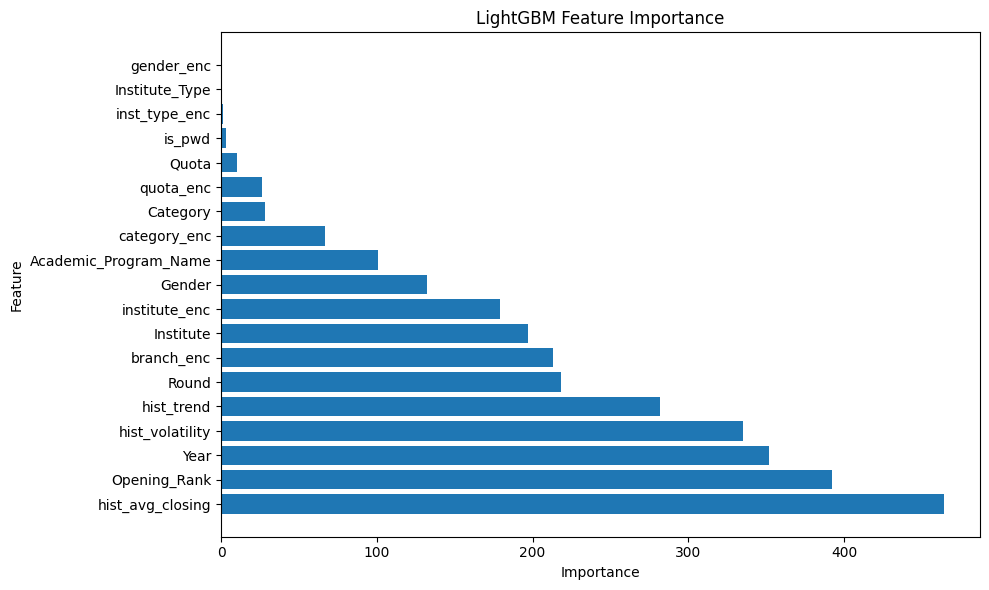

In [317]:

import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



# Features and target
X = df.drop(columns=['Closing_Rank'])
y = df['Closing_Rank']


# Categorical columns
categorical_cols = [
    'Institute',
    'Academic_Program_Name',
    'Quota',
    'Gender',
    'Category',
    'Institute_Type'
]


# Convert object → category
for col in categorical_cols:
    X[col] = X[col].astype('category')


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# LightGBM
model = lgb.LGBMRegressor(
    n_estimators=100,
    random_state=42
)


model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)


# Feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)


print(importance.to_string(index=False))


# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")

plt.tight_layout()
plt.show()


In [318]:
!pip install lightgbm xgboost catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.1 MB/s eta 0:00:00


In [319]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

In [320]:
features = [
    'institute_enc',
    'branch_enc',
    'quota_enc',
    'gender_enc',
    'category_enc',
    'inst_type_enc',
    'Opening_Rank',
    'Round',
    'Year',
    'is_pwd',
    'hist_avg_closing',
    'hist_trend',
    'hist_volatility'
]

target = 'Closing_Rank'

In [321]:
model_df = df.dropna(
    subset=['hist_avg_closing']
).copy()


In [322]:
train_df = model_df[model_df['Year'] < 2026].copy()
test_df  = model_df[model_df['Year'] == 2026].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (221434, 13)
Test : (10589, 13)


In [323]:
models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=False
    )
}

In [324]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    trained_models[name] = model

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")


Training Random Forest...
MAE  : 1665.11
RMSE : 12073.89
R²   : 0.8984

Training XGBoost...
MAE  : 1807.16
RMSE : 12825.03
R²   : 0.8853

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1358
[LightGBM] [Info] Number of data points in the train set: 221434, number of used features: 13
[LightGBM] [Info] Start training from score 14431.074672
MAE  : 1896.67
RMSE : 12635.64
R²   : 0.8887

Training CatBoost...
MAE  : 1886.52
RMSE : 12872.45
R²   : 0.8845


In [325]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='MAE',
    ascending=True
)

print("\n========== MODEL COMPARISON ==========")
print(results_df.to_string(index=False))


========== MODEL COMPARISON ==========
        Model         MAE         RMSE       R2
Random Forest 1665.113421 12073.890540 0.898351
      XGBoost 1807.162354 12825.029902 0.885310
     CatBoost 1886.523831 12872.451606 0.884460
     LightGBM 1896.673766 12635.644040 0.888672


In [331]:
best_model_name = results_df.iloc[0]['Model']

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [329]:
best_model = trained_models["Random Forest"]

print("Best Model:", type(best_model).__name__)

Best Model: RandomForestRegressor


In [332]:
print(df['Year'].unique())

[2021 2022 2023 2024 2025 2026 2020]


In [333]:
import os
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(
    best_model,
    "model/random_forest_model.pkl"
)

joblib.dump(
    encoders,
    "model/encoders.pkl"
)

joblib.dump(
    features,
    "model/features.pkl"
)

print("✅ Random Forest saved")
print("✅ Encoders saved")
print("✅ Features saved")

✅ Random Forest saved
✅ Encoders saved
✅ Features saved


In [334]:
features

['institute_enc',
 'branch_enc',
 'quota_enc',
 'gender_enc',
 'category_enc',
 'inst_type_enc',
 'Opening_Rank',
 'Round',
 'Year',
 'is_pwd',
 'hist_avg_closing',
 'hist_trend',
 'hist_volatility']

## **PART - 3 (End Part)**

In [335]:
import joblib

model = joblib.load("model/random_forest_model.pkl")
encoders = joblib.load("model/encoders.pkl")
features = joblib.load("model/features.pkl")

print("✅ Model loaded")
print("✅ Encoders loaded")
print("✅ Features loaded")

print("\nFeatures:")
print(features)

✅ Model loaded
✅ Encoders loaded
✅ Features loaded

Features:
['institute_enc', 'branch_enc', 'quota_enc', 'gender_enc', 'category_enc', 'inst_type_enc', 'Opening_Rank', 'Round', 'Year', 'is_pwd', 'hist_avg_closing', 'hist_trend', 'hist_volatility']


In [338]:
student = {
    "Exam": "JEE Advanced",   # "JEE Main" or "JEE Advanced"
    "Category": "OPEN",
    "Quota": "AI",
    "Gender": "Gender-Neutral",
    "is_pwd": 0,
    "Rank": 15000
}

print(student)

{'Exam': 'JEE Advanced', 'Category': 'OPEN', 'Quota': 'AI', 'Gender': 'Gender-Neutral', 'is_pwd': 0, 'Rank': 15000}


In [339]:
for col, encoder in encoders.items():
    print(f"\n{col}:")
    print(encoder.classes_)


Institute:
['Assam University, Silchar'
 'Atal Bihari Vajpayee Indian Institute of Information Technology & Management Gwalior'
 'Birla Institute of Technology, Deoghar Off-Campus'
 'Birla Institute of Technology, Mesra, Ranchi'
 'Birla Institute of Technology, Patna Off-Campus'
 'Central University of Haryana' 'Central University of Jammu'
 'Central University of Rajasthan, Rajasthan'
 'Central institute of Technology Kokrajar, Assam'
 'Chhattisgarh Swami Vivekanada Technical University, Bhilai (CSVTU Bhilai)'
 'Dr. B R Ambedkar National Institute of Technology, Jalandhar'
 'Gati Shakti Vishwavidyalaya, Vadodara'
 'Ghani Khan Choudhary Institute of Engineering and Technology, Malda, West Bengal'
 'Gurukula Kangri Vishwavidyalaya, Haridwar'
 'HNB Garhwal University Srinagar (Garhwal)'
 'INDIAN INSTITUTE OF INFORMATION TECHNOLOGY SENAPATI MANIPUR'
 'Indian Institute of Carpet Technology, Bhadohi'
 'Indian Institute of Engineering Science and Technology, Shibpur'
 'Indian Institute of H

In [340]:
exam = "JEE Advanced"

print("Selected Exam:", exam)

Selected Exam: JEE Advanced


In [341]:
if exam == "JEE Advanced":
    exam_df = df[df["Institute_Type"] == "IIT"].copy()
else:
    exam_df = df[df["Institute_Type"] != "IIT"].copy()

print("Exam:", exam)
print("Institute Types:")
print(exam_df["Institute_Type"].value_counts())

Exam: JEE Advanced
Institute Types:
Institute_Type
IIT    61606
Name: count, dtype: int64


In [346]:
print(exam_df["Institute"].unique())
exam_df['Institute'].size

['Indian Institute of Technology (BHU) Varanasi'
 'Indian Institute of Technology (ISM) Dhanbad'
 'Indian Institute of Technology Bhilai'
 'Indian Institute of Technology Bhubaneswar'
 'Indian Institute of Technology Bombay'
 'Indian Institute of Technology Delhi'
 'Indian Institute of Technology Dharwad'
 'Indian Institute of Technology Gandhinagar'
 'Indian Institute of Technology Goa'
 'Indian Institute of Technology Guwahati'
 'Indian Institute of Technology Hyderabad'
 'Indian Institute of Technology Indore'
 'Indian Institute of Technology Jammu'
 'Indian Institute of Technology Jodhpur'
 'Indian Institute of Technology Kanpur'
 'Indian Institute of Technology Kharagpur'
 'Indian Institute of Technology Madras'
 'Indian Institute of Technology Mandi'
 'Indian Institute of Technology Palakkad'
 'Indian Institute of Technology Patna'
 'Indian Institute of Technology Roorkee'
 'Indian Institute of Technology Ropar'
 'Indian Institute of Technology Tirupati']


61606

In [343]:
student = {
    "Category": "OPEN",
    "Quota": "AI",
    "Gender": "Gender-Neutral",
    "is_pwd": 0,
    "Rank": 15000
}

print(student)

{'Category': 'OPEN', 'Quota': 'AI', 'Gender': 'Gender-Neutral', 'is_pwd': 0, 'Rank': 15000}


In [344]:
filtered_df = exam_df[
    (exam_df["Category"] == student["Category"]) &
    (exam_df["Quota"] == student["Quota"]) &
    (exam_df["Gender"] == student["Gender"]) &
    (exam_df["is_pwd"] == student["is_pwd"])
].copy()

print("Filtered records:", len(filtered_df))
print("\nInstitute Types:")
print(filtered_df["Institute_Type"].value_counts())

Filtered records: 6569

Institute Types:
Institute_Type
IIT    6569
Name: count, dtype: int64


In [348]:
print(filtered_df["Round"].value_counts().sort_index())

Round
1    1265
2    1326
3    1326
4    1326
5    1326
Name: count, dtype: int64


In [349]:
print("Minimum Closing Rank:", filtered_df["Closing_Rank"].min())
print("Maximum Closing Rank:", filtered_df["Closing_Rank"].max())

Minimum Closing Rank: 60
Maximum Closing Rank: 26220


In [350]:
print(filtered_df[["Institute", "Academic_Program_Name",
                   "Opening_Rank", "Closing_Rank", "Round", "Year"]].head(10))

                                            Institute  \
65931   Indian Institute of Technology (BHU) Varanasi   
56692   Indian Institute of Technology (BHU) Varanasi   
93601   Indian Institute of Technology (BHU) Varanasi   
75198   Indian Institute of Technology (BHU) Varanasi   
131831  Indian Institute of Technology (BHU) Varanasi   
141844  Indian Institute of Technology (BHU) Varanasi   
151658  Indian Institute of Technology (BHU) Varanasi   
161432  Indian Institute of Technology (BHU) Varanasi   
112321  Indian Institute of Technology (BHU) Varanasi   
202627  Indian Institute of Technology (BHU) Varanasi   

                                   Academic_Program_Name  Opening_Rank  \
65931   Architecture (5 Years, Bachelor of Architecture)         16850   
56692   Architecture (5 Years, Bachelor of Architecture)         16850   
93601   Architecture (5 Years, Bachelor of Architecture)         16850   
75198   Architecture (5 Years, Bachelor of Architecture)         16850   
13

In [352]:
rank = student["Rank"]

rank_match = filtered_df[
    (filtered_df["Opening_Rank"] <= rank) &
    (filtered_df["Closing_Rank"] >= rank)
].copy()

print("Matching records:", len(rank_match))

Matching records: 159


In [353]:
print(
    rank_match[
        ["Opening_Rank", "Closing_Rank", "Round", "Year"]
    ].head(20)
)

        Opening_Rank  Closing_Rank  Round  Year
213186         14864         15731      2  2023
234004         13369         16011      5  2024
302982         13511         15446      2  2025
291000         13511         15594      3  2025
351215         13511         15633      4  2025
339247         13511         15633      5  2025
213194         14423         15340      2  2023
171186         14423         15592      3  2023
191957         14423         15592      4  2023
223667         14423         15731      5  2023
302991         10750         15139      2  2025
291009         10750         15139      3  2025
351224         10750         15139      4  2025
339256         10750         15201      5  2025
223743         12849         15044      5  2023
234084          9606         15291      5  2024
363476         12890         15086      1  2026
223783          8548         15062      5  2023
213320         13568         15241      2  2023
171312         13568         15334      

In [354]:
print(
    (
        (rank_match["Opening_Rank"] <= rank) &
        (rank_match["Closing_Rank"] >= rank)
    ).all()
)

True


In [355]:
print(
    rank_match[
        [
            "Institute",
            "Academic_Program_Name",
            "Opening_Rank",
            "Closing_Rank",
            "Round",
            "Year"
        ]
    ].head(20).to_string(index=False)
)


                                   Institute                                          Academic_Program_Name  Opening_Rank  Closing_Rank  Round  Year
Indian Institute of Technology (ISM) Dhanbad     Applied Geology (5 Years, Integrated Master of Technology)         14864         15731      2  2023
Indian Institute of Technology (ISM) Dhanbad     Applied Geology (5 Years, Integrated Master of Technology)         13369         16011      5  2024
Indian Institute of Technology (ISM) Dhanbad     Applied Geology (5 Years, Integrated Master of Technology)         13511         15446      2  2025
Indian Institute of Technology (ISM) Dhanbad     Applied Geology (5 Years, Integrated Master of Technology)         13511         15594      3  2025
Indian Institute of Technology (ISM) Dhanbad     Applied Geology (5 Years, Integrated Master of Technology)         13511         15633      4  2025
Indian Institute of Technology (ISM) Dhanbad     Applied Geology (5 Years, Integrated Master of Technology

In [356]:
college_branch = rank_match[
    ["Institute", "Academic_Program_Name"]
].drop_duplicates()

print("Unique College + Branch options:", len(college_branch))

print(
    college_branch.head(20).to_string(index=False)
)

Unique College + Branch options: 22
                                   Institute                                                                                                 Academic_Program_Name
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)
Indian Institute of Technology (ISM) Dhanbad                                                                  Mining Engineering (4 Years, Bachelor of Technology)
Indian Institute of Technology (ISM) Dhanbad                                                        Mining Machinery Engineering (4 Years, Bachelor o

In [359]:
latest_options = (
    rank_match
    .sort_values(
        ["Institute", "Academic_Program_Name", "Year", "Round"]
    )
    .groupby(
        ["Institute", "Academic_Program_Name"],
        as_index=False
    )
    .tail(1)
    .copy()
)

print("Unique College + Branch options:", len(latest_options))

print(
    latest_options[
        [
            "Institute",
            "Academic_Program_Name",
            "Opening_Rank",
            "Closing_Rank",
            "Round",
            "Year",
            "hist_avg_closing",
            "hist_trend",
            "hist_volatility"
        ]
    ].to_string(index=False)
)

Unique College + Branch options: 22
                                   Institute                                                                                                 Academic_Program_Name  Opening_Rank  Closing_Rank  Round  Year  hist_avg_closing  hist_trend  hist_volatility
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)         13511         15633      5  2025      15557.666667  232.000000        98.652589
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)         10750         15201      5  2025      15139.000000  140.333333         0.000000
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)         12890         15086      1  2026      14

In [360]:
features = [
    'institute_enc',
    'branch_enc',
    'quota_enc',
    'gender_enc',
    'category_enc',
    'inst_type_enc',
    'Opening_Rank',
    'Round',
    'Year',
    'is_pwd',
    'hist_avg_closing',
    'hist_trend',
    'hist_volatility'
]

In [361]:
for col, new_col in {
    'Institute': 'institute_enc',
    'Academic_Program_Name': 'branch_enc',
    'Quota': 'quota_enc',
    'Gender': 'gender_enc',
    'Category': 'category_enc',
    'Institute_Type': 'inst_type_enc'
}.items():

    latest_options[new_col] = encoders[col].transform(
        latest_options[col].astype(str)
    )

print("Encoding completed.")

print(
    latest_options[
        [
            'Institute',
            'Academic_Program_Name',
            'institute_enc',
            'branch_enc',
            'category_enc',
            'quota_enc'
        ]
    ].head()
)

Encoding completed.
                                           Institute  \
339247  Indian Institute of Technology (ISM) Dhanbad   
339256  Indian Institute of Technology (ISM) Dhanbad   
363476  Indian Institute of Technology (ISM) Dhanbad   
223783  Indian Institute of Technology (ISM) Dhanbad   
363547  Indian Institute of Technology (ISM) Dhanbad   

                                    Academic_Program_Name  institute_enc  \
339247  Applied Geology (5 Years, Integrated Master of...             44   
339256  Applied Geophysics (5 Years, Integrated Master...             44   
363476  Environmental Engineering (4 Years, Bachelor o...             44   
223783  Mining Engineering (4 Years, Bachelor of Techn...             44   
363547  Mining Machinery Engineering (4 Years, Bachelo...             44   

        branch_enc  category_enc  quota_enc  
339247           7             2          0  
339256           8             2          0  
363476         163             2          0  
22

In [362]:
X_predict = latest_options[features]

predicted_closing = best_model.predict(X_predict)

latest_options["Predicted_Closing_Rank"] = predicted_closing

print(
    latest_options[
        [
            "Institute",
            "Academic_Program_Name",
            "Opening_Rank",
            "Closing_Rank",
            "Predicted_Closing_Rank",
            "Round",
            "Year"
        ]
    ].to_string(index=False)
)

                                   Institute                                                                                                 Academic_Program_Name  Opening_Rank  Closing_Rank  Predicted_Closing_Rank  Round  Year
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)         13511         15633            15710.703365      5  2025
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)         10750         15201            15421.980409      5  2025
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)         12890         15086            14494.014817      1  2026
Indian Institute of Technology (ISM) Dhanbad                                            

In [363]:
rank = student["Rank"]

def get_chance(predicted_rank, student_rank):

    if student_rank <= predicted_rank:
        return "HIGH"
    elif student_rank <= predicted_rank * 1.10:
        return "MEDIUM"
    else:
        return "LOW"


latest_options["Chance"] = latest_options["Predicted_Closing_Rank"].apply(
    lambda x: get_chance(x, rank)
)

print(
    latest_options[
        [
            "Institute",
            "Academic_Program_Name",
            "Opening_Rank",
            "Closing_Rank",
            "Predicted_Closing_Rank",
            "Round",
            "Year",
            "Chance"
        ]
    ].to_string(index=False)
)

                                   Institute                                                                                                 Academic_Program_Name  Opening_Rank  Closing_Rank  Predicted_Closing_Rank  Round  Year Chance
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)         13511         15633            15710.703365      5  2025   HIGH
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)         10750         15201            15421.980409      5  2025   HIGH
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)         12890         15086            14494.014817      1  2026 MEDIUM
Indian Institute of Technology (ISM) Dhanbad                

In [364]:
latest_options["Rank_Difference"] = (
    latest_options["Predicted_Closing_Rank"] - student["Rank"]
)

print(
    latest_options[
        [
            "Institute",
            "Academic_Program_Name",
            "Opening_Rank",
            "Closing_Rank",
            "Predicted_Closing_Rank",
            "Rank_Difference",
            "Chance"
        ]
    ].to_string(index=False)
)

                                   Institute                                                                                                 Academic_Program_Name  Opening_Rank  Closing_Rank  Predicted_Closing_Rank  Rank_Difference Chance
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)         13511         15633            15710.703365       710.703365   HIGH
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)         10750         15201            15421.980409       421.980409   HIGH
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)         12890         15086            14494.014817      -505.985183 MEDIUM
Indian Institute of Technology (ISM) Dhanbad

In [365]:
latest_options["Margin_Percent"] = (
    latest_options["Rank_Difference"]
    / latest_options["Predicted_Closing_Rank"]
) * 100

print(
    latest_options[
        [
            "Institute",
            "Academic_Program_Name",
            "Predicted_Closing_Rank",
            "Rank_Difference",
            "Margin_Percent",
            "Chance"
        ]
    ].to_string(index=False)
)

                                   Institute                                                                                                 Academic_Program_Name  Predicted_Closing_Rank  Rank_Difference  Margin_Percent Chance
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)            15710.703365       710.703365        4.523689   HIGH
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)            15421.980409       421.980409        2.736227   HIGH
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)            14494.014817      -505.985183       -3.490994 MEDIUM
Indian Institute of Technology (ISM) Dhanbad                                                

In [366]:
def get_chance_by_margin(margin):

    if margin >= 5:
        return "HIGH"
    elif margin >= 0:
        return "MEDIUM"
    else:
        return "LOW"


latest_options["Chance_New"] = latest_options["Margin_Percent"].apply(
    get_chance_by_margin
)

print(
    latest_options[
        [
            "Institute",
            "Academic_Program_Name",
            "Predicted_Closing_Rank",
            "Rank_Difference",
            "Margin_Percent",
            "Chance_New"
        ]
    ].to_string(index=False)
)

                                   Institute                                                                                                 Academic_Program_Name  Predicted_Closing_Rank  Rank_Difference  Margin_Percent Chance_New
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)            15710.703365       710.703365        4.523689     MEDIUM
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)            15421.980409       421.980409        2.736227     MEDIUM
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)            14494.014817      -505.985183       -3.490994        LOW
Indian Institute of Technology (ISM) Dhanbad                                

In [367]:
final_result = latest_options[
    [
        "Institute",
        "Academic_Program_Name",
        "Opening_Rank",
        "Closing_Rank",
        "Predicted_Closing_Rank",
        "Round",
        "Year",
        "Chance_New"
    ]
].copy()

final_result = final_result.rename(
    columns={
        "Academic_Program_Name": "Branch",
        "Chance_New": "Chance"
    }
)

final_result["Predicted_Closing_Rank"] = (
    final_result["Predicted_Closing_Rank"].round().astype(int)
)

print(final_result.to_string(index=False))

                                   Institute                                                                                                                Branch  Opening_Rank  Closing_Rank  Predicted_Closing_Rank  Round  Year Chance
Indian Institute of Technology (ISM) Dhanbad                                                            Applied Geology (5 Years, Integrated Master of Technology)         13511         15633                   15711      5  2025 MEDIUM
Indian Institute of Technology (ISM) Dhanbad                                                         Applied Geophysics (5 Years, Integrated Master of Technology)         10750         15201                   15422      5  2025 MEDIUM
Indian Institute of Technology (ISM) Dhanbad                                                           Environmental Engineering (4 Years, Bachelor of Technology)         12890         15086                   14494      1  2026    LOW
Indian Institute of Technology (ISM) Dhanbad                

In [370]:
def predict_colleges(
    exam,
    category,
    quota,
    gender,
    is_pwd,
    rank
):

    student = {
        "Exam": exam,
        "Category": category,
        "Quota": quota,
        "Gender": gender,
        "is_pwd": is_pwd,
        "Rank": rank
    }

    print("Student Details")
    print("----------------")
    print("Exam    :", exam)
    print("Category:", category)
    print("Quota   :", quota)
    print("Gender  :", gender)
    print("PwD     :", is_pwd)
    print("Rank    :", rank)

In [371]:
predict_colleges(
    exam="JEE Advanced",
    category="OPEN",
    quota="AI",
    gender="Gender-Neutral",
    is_pwd=0,
    rank=15000
)

Student Details
----------------
Exam    : JEE Advanced
Category: OPEN
Quota   : AI
Gender  : Gender-Neutral
PwD     : 0
Rank    : 15000


In [372]:
def predict_colleges(
    exam,
    category,
    quota,
    gender,
    is_pwd,
    rank
):

    student = {
        "Exam": exam,
        "Category": category,
        "Quota": quota,
        "Gender": gender,
        "is_pwd": is_pwd,
        "Rank": rank
    }

    # Step 1: Exam filtering
    if exam == "JEE Advanced":
        exam_df = df[df["Institute_Type"] == "IIT"].copy()
    else:
        exam_df = df[df["Institute_Type"] != "IIT"].copy()

    print("Student Details")
    print("----------------")
    print("Exam    :", exam)
    print("Category:", category)
    print("Quota   :", quota)
    print("Gender  :", gender)
    print("PwD     :", is_pwd)
    print("Rank    :", rank)

    print("\nAfter Exam Filtering:")
    print(exam_df["Institute_Type"].value_counts())

In [373]:
predict_colleges(
    exam="JEE Advanced",
    category="OPEN",
    quota="AI",
    gender="Gender-Neutral",
    is_pwd=0,
    rank=15000
)

Student Details
----------------
Exam    : JEE Advanced
Category: OPEN
Quota   : AI
Gender  : Gender-Neutral
PwD     : 0
Rank    : 15000

After Exam Filtering:
Institute_Type
IIT    61606
Name: count, dtype: int64


In [374]:
def predict_colleges(
    exam,
    category,
    quota,
    gender,
    is_pwd,
    rank
):

    student = {
        "Exam": exam,
        "Category": category,
        "Quota": quota,
        "Gender": gender,
        "is_pwd": is_pwd,
        "Rank": rank
    }

    # Step 1: Exam filtering
    if exam == "JEE Advanced":
        exam_df = df[df["Institute_Type"] == "IIT"].copy()
    else:
        exam_df = df[df["Institute_Type"] != "IIT"].copy()

    # Step 2: Student preference filtering
    filtered_df = exam_df[
        (exam_df["Category"] == category) &
        (exam_df["Quota"] == quota) &
        (exam_df["Gender"] == gender) &
        (exam_df["is_pwd"] == is_pwd)
    ].copy()

    print("Student Details")
    print("----------------")
    print("Exam    :", exam)
    print("Category:", category)
    print("Quota   :", quota)
    print("Gender  :", gender)
    print("PwD     :", is_pwd)
    print("Rank    :", rank)

    print("\nAfter Exam Filtering:")
    print(exam_df["Institute_Type"].value_counts())

    print("\nAfter Student Filtering:")
    print("Matching records:", len(filtered_df))

In [375]:
predict_colleges(
    exam="JEE Advanced",
    category="OPEN",
    quota="AI",
    gender="Gender-Neutral",
    is_pwd=0,
    rank=15000
)

Student Details
----------------
Exam    : JEE Advanced
Category: OPEN
Quota   : AI
Gender  : Gender-Neutral
PwD     : 0
Rank    : 15000

After Exam Filtering:
Institute_Type
IIT    61606
Name: count, dtype: int64

After Student Filtering:
Matching records: 6569


In [423]:
def predict_colleges(
    exam,
    category,
    quota,
    gender,
    is_pwd,
    rank
):

    student = {
        "Exam": exam,
        "Category": category,
        "Quota": quota,
        "Gender": gender,
        "is_pwd": is_pwd,
        "Rank": rank
    }

    # Step 1: Exam filtering
    if exam == "JEE Advanced":
        exam_df = df[df["Institute_Type"] == "IIT"].copy()
    else:
        exam_df = df[df["Institute_Type"] != "IIT"].copy()

    # Step 2: Category + Quota + Gender + PwD
    filtered_df = exam_df[
        (exam_df["Category"] == category) &
        (exam_df["Quota"] == quota) &
        (exam_df["Gender"] == gender) &
        (exam_df["is_pwd"] == is_pwd)
    ].copy()

    # # Step 3: Rank filtering
    # rank_match = filtered_df[
    #     (filtered_df["Opening_Rank"] <= rank) &
    #     (filtered_df["Closing_Rank"] >= rank)
    # ].copy()

    # print("Student Details")
    # print("----------------")
    # print("Exam    :", exam)
    # print("Category:", category)
    # print("Quota   :", quota)
    # print("Gender  :", gender)
    # print("PwD     :", is_pwd)
    # print("Rank    :", rank)

    # print("\nAfter Exam Filtering:")
    # print(exam_df["Institute_Type"].value_counts())

    # print("\nAfter Student Filtering:")
    # print("Matching records:", len(filtered_df))

    # print("\nAfter Rank Filtering:")
    # print("Rank matching records:", len(rank_match))

    # # Step 3.1: Handle No Rank Match
    # if rank_match.empty:
    #     print("\nNo college or branch found for the given inputs.")
    #     return pd.DataFrame()
    # Step 3: College + Branch Candidates

    rank_match = filtered_df.copy()

    print("\nCandidate records:", len(rank_match))

    # Step 3.1: Handle No Candidate
    if rank_match.empty:
        print("\nNo college or branch found for the given inputs.")
        return pd.DataFrame()

    # Step 4: Latest College + Branch option
    latest_options = (
        rank_match
        .sort_values(
            ["Institute", "Academic_Program_Name", "Year", "Round"]
        )
        .groupby(
            ["Institute", "Academic_Program_Name"],
            as_index=False
        )
        .tail(1)
        .copy()
    )

    print(
        "\nUnique College + Branch options:",
        len(latest_options)
    )

    # Step 5: Encode categorical features
    for col, new_col in {
        'Institute': 'institute_enc',
        'Academic_Program_Name': 'branch_enc',
        'Quota': 'quota_enc',
        'Gender': 'gender_enc',
        'Category': 'category_enc',
        'Institute_Type': 'inst_type_enc'
    }.items():

        latest_options[new_col] = encoders[col].transform(
            latest_options[col].astype(str)
        )

    print("\nEncoding completed.")

    # Step 6: Predict Closing Rank
    X_predict = latest_options[features]

    predicted_closing = best_model.predict(X_predict)

    latest_options["Predicted_Closing_Rank"] = predicted_closing

    print("\nPrediction completed.")

    # Step 7: Check Predictions
    print(
        latest_options[
            [
                "Institute",
                "Academic_Program_Name",
                "Opening_Rank",
                "Closing_Rank",
                "Predicted_Closing_Rank",
                "Round",
                "Year"
            ]
        ].to_string(index=False)
    )

    # Step 8: Rank Difference
    latest_options["Rank_Difference"] = (
        latest_options["Predicted_Closing_Rank"] - rank
    )

    print("\nRank Difference calculated.")

    # Step 9: Check Rank Difference
    print(
        latest_options[
            [
                "Institute",
                "Academic_Program_Name",
                "Opening_Rank",
                "Closing_Rank",
                "Predicted_Closing_Rank",
                "Rank_Difference",
                "Round",
                "Year"
            ]
        ].to_string(index=False)
    )

    # Step 10: Calculate Margin Percentage
    latest_options["Margin_Percent"] = (
        latest_options["Rank_Difference"]
        / latest_options["Predicted_Closing_Rank"]
    ) * 100

    print("\nMargin Percentage calculated.")

    # Step 11: Calculate Chance
    def get_chance(margin):

        if margin >= 5:
            return "HIGH"
        elif margin >= 0:
            return "MEDIUM"
        else:
            return "LOW"

    latest_options["Chance"] = (
        latest_options["Margin_Percent"]
        .apply(get_chance)
    )

    print("\nChance calculated.")

    # Step 12: Sort Final Results
    chance_order = {
        "HIGH": 0,
        "MEDIUM": 1,
        "LOW": 2
    }

    latest_options["Chance_Order"] = (
        latest_options["Chance"].map(chance_order)
    )

    latest_options = latest_options.sort_values(
        ["Chance_Order", "Predicted_Closing_Rank"]
    )

    # Step 13: Final Result
    final_result = latest_options[
        [
            "Institute",
            "Academic_Program_Name",
            "Opening_Rank",
            "Closing_Rank",
            "Predicted_Closing_Rank",
            "Round",
            "Year",
            "Chance"
        ]
    ].copy()

    final_result = final_result.rename(
        columns={
            "Academic_Program_Name": "Branch"
        }
    )

    final_result["Predicted_Closing_Rank"] = (
        final_result["Predicted_Closing_Rank"]
        .round()
        .astype(int)
    )

    print("\n========== FINAL RESULT ==========")
    print(final_result.to_string(index=False))

    # Step 14: Return Final Result
    return final_result

In [424]:
predict_colleges(
    exam="JEE Advanced",
    category="OPEN",
    quota="AI",
    gender="Gender-Neutral",
    is_pwd=0,
    rank=15000
)


Candidate records: 6569

Unique College + Branch options: 333

Encoding completed.

Prediction completed.
                                    Institute                                                                                                                                                  Academic_Program_Name  Opening_Rank  Closing_Rank  Predicted_Closing_Rank  Round  Year
Indian Institute of Technology (BHU) Varanasi                                                                                                                       Architecture (5 Years, Bachelor of Architecture)         15019         26220            19248.627623      1  2026
Indian Institute of Technology (BHU) Varanasi                           Biochemical Engineering with M.Tech. in Biochemical Engineering and Biotechnology (5 Years, Bachelor and Master of Technology (Dual Degree))         10717         12761            12669.597214      5  2024
Indian Institute of Technology (BHU) Varanasi              

,Institute,Branch,Opening_Rank,Closing_Rank,Predicted_Closing_Rank,Round,Year,Chance
363171,Indian Institute of Technology Roorkee,"Architecture (5 Years, Bachelor of Architecture)",13547,18684,16161,1,2026,HIGH
361395,Indian Institute of Technology Mandi,"BS in Chemical Sciences (4 Years, Bachelor of ...",14455,16066,16172,1,2026,HIGH
340117,Indian Institute of Technology Jammu,"Materials Engineering (4 Years, Bachelor of Te...",15530,16096,16228,5,2025,HIGH
364362,Indian Institute of Technology Dharwad,"Civil and Infrastructure Engineering (4 Years,...",14903,15934,16246,1,2026,HIGH
364271,Indian Institute of Technology Jammu,"Civil Engineering (4 Years, Bachelor of Techno...",15027,15466,16289,1,2026,HIGH
...,...,...,...,...,...,...,...,...
363161,Indian Institute of Technology Patna,Metallurgical and Materials Engineering (4 Yea...,12743,14611,14645,1,2026,LOW
364211,Indian Institute of Technology Tirupati,"Civil Engineering (4 Years, Bachelor of Techno...",12608,15388,14707,1,2026,LOW
221695,Indian Institute of Technology Bhubaneswar,Metallurgical and Materials Engineering (5 Yea...,14409,14786,14892,5,2023,LOW
221582,Indian Institute of Technology Bhubaneswar,Civil Engineering and M.Tech in Transportation...,14479,14924,14895,5,2023,LOW


In [425]:
predict_colleges(
    exam="JEE Advanced",
    category="OPEN",
    quota="AI",
    gender="Gender-Neutral",
    is_pwd=0,
    rank=1000
)


Candidate records: 6569

Unique College + Branch options: 333

Encoding completed.

Prediction completed.
                                    Institute                                                                                                                                                  Academic_Program_Name  Opening_Rank  Closing_Rank  Predicted_Closing_Rank  Round  Year
Indian Institute of Technology (BHU) Varanasi                                                                                                                       Architecture (5 Years, Bachelor of Architecture)         15019         26220            19248.627623      1  2026
Indian Institute of Technology (BHU) Varanasi                           Biochemical Engineering with M.Tech. in Biochemical Engineering and Biotechnology (5 Years, Bachelor and Master of Technology (Dual Degree))         10717         12761            12669.597214      5  2024
Indian Institute of Technology (BHU) Varanasi              

,Institute,Branch,Opening_Rank,Closing_Rank,Predicted_Closing_Rank,Round,Year,Chance
362613,Indian Institute of Technology Kanpur,"Statistics and Data Science (4 Years, Bachelor...",596,1299,1063,1,2026,HIGH
361295,Indian Institute of Technology Bombay,Industrial Engineering and Operations Research...,448,834,1068,1,2026,HIGH
362539,Indian Institute of Technology Kanpur,"Electrical Engineering (4 Years, Bachelor of T...",616,1151,1093,1,2026,HIGH
363943,Indian Institute of Technology Guwahati,Data Science and Artificial Intelligence (4 Ye...,1029,1259,1126,1,2026,HIGH
364003,Indian Institute of Technology Guwahati,"Mathematics and Computing (4 Years, Bachelor o...",943,1325,1182,1,2026,HIGH
...,...,...,...,...,...,...,...,...
362149,Indian Institute of Technology Hyderabad,"Artificial Intelligence (4 Years, Bachelor of ...",696,906,861,1,2026,LOW
362295,Indian Institute of Technology Hyderabad,"Mathematics and Computing (4 Years, Bachelor o...",745,916,901,1,2026,LOW
362578,Indian Institute of Technology Kanpur,"Mathematics and Scientific Computing (4 Years,...",246,1258,933,1,2026,LOW
361158,Indian Institute of Technology Bombay,"BS in Mathematics (4 Years, Bachelor of Science)",827,1042,960,1,2026,LOW


In [444]:
predict_colleges(
    exam="JEE Advanced",
    category="EWS",
    quota="AI",
    gender="Gender-Neutral",
    is_pwd=0,
    rank=5002
)


Candidate records: 6538

Unique College + Branch options: 327

Encoding completed.

Prediction completed.
                                    Institute                                                                                                                                                  Academic_Program_Name  Opening_Rank  Closing_Rank  Predicted_Closing_Rank  Round  Year
Indian Institute of Technology (BHU) Varanasi                                                                                                                       Architecture (5 Years, Bachelor of Architecture)          4003          4217             4105.271320      1  2026
Indian Institute of Technology (BHU) Varanasi                           Biochemical Engineering with M.Tech. in Biochemical Engineering and Biotechnology (5 Years, Bachelor and Master of Technology (Dual Degree))          1976          2090             2095.595579      5  2024
Indian Institute of Technology (BHU) Varanasi              

,Institute,Branch,Opening_Rank,Closing_Rank,Predicted_Closing_Rank,Round,Year,Chance
361207,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",6,20,21,1,2026,LOW
362727,Indian Institute of Technology Madras,"Computer Science and Engineering (4 Years, Bac...",22,31,27,1,2026,LOW
361584,Indian Institute of Technology Delhi,"Computer Science and Engineering (4 Years, Bac...",24,35,34,1,2026,LOW
362505,Indian Institute of Technology Kanpur,"Computer Science and Engineering (4 Years, Bac...",32,48,48,1,2026,LOW
362644,Indian Institute of Technology Madras,Artificial Intelligence and Data Analytics (4 ...,37,65,58,1,2026,LOW
...,...,...,...,...,...,...,...,...
221697,Indian Institute of Technology Bhubaneswar,Metallurgical and Materials Engineering (5 Yea...,2469,2481,2482,5,2023,LOW
340206,Indian Institute of Technology Dharwad,"Interdisciplinary Sciences (5 Years, Bachelor ...",2406,2514,2519,5,2025,LOW
363173,Indian Institute of Technology Roorkee,"Architecture (5 Years, Bachelor of Architecture)",2789,2963,2811,1,2026,LOW
361908,Indian Institute of Technology Kharagpur,"Architecture (5 Years, Bachelor of Architecture)",3312,3337,3470,1,2026,LOW


In [442]:
# pre1['Institute'].value_counts()

,count
Institute,
Indian Institute of Technology Kharagpur,38
Indian Institute of Technology Patna,33
Indian Institute of Technology (BHU) Varanasi,25
Indian Institute of Technology Roorkee,19
Indian Institute of Technology Bombay,19
Indian Institute of Technology Delhi,17
Indian Institute of Technology Madras,17
Indian Institute of Technology Bhubaneswar,16
Indian Institute of Technology (ISM) Dhanbad,16


In [445]:
train_df = df[df["Year"] < 2026].copy()
test_df = df[df["Year"] == 2026].copy()

print("Training data:", train_df.shape)
print("Testing data :", test_df.shape)

Training data: (221434, 20)
Testing data : (10589, 20)


In [446]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [447]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [448]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1665.1134206907072
RMSE: 12073.890539653234
R²  : 0.8983505591310575


In [2]:
# Time-based train-test split

train_df = df[df["Year"] < 2026].copy()
test_df = df[df["Year"] == 2026].copy()

# Features and target
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training data:", train_df.shape)
print("Testing data :", test_df.shape)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

NameError: name 'df' is not defined

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# IMPORTANT: predict using rf_model
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Time-Based Validation")
print("---------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

NameError: name 'X_train' is not defined